# 02 · Sweeps and results

Part 1 built programs that run once. Every calibration is a loop, and three pieces turn a sequence into one. A variable is the hole in the program where the knob goes, a sweep source says how that knob moves, and `average(shots)` repeats the whole thing.

The other half is the data. `qp.simulate` returns labeled arrays whose axes are named after the variables you declared, and which know enough to draw themselves.

Two programs carry the part. Resonator spectroscopy is one sweep and finds the readout resonator. Punchout wraps a second sweep around it and says how hard you may drive the tone.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0", "scipy"],
        check=True,
    )
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.1.0


In [2]:
import numpy as np

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram.buses import BusSchema
from qprogram.plotting import Quantity, Style
from qprogram.waveforms import IQZero, Square

schema = BusSchema.transmon()
q = schema.q

## 2.0 The device

Every part writes down the numbers it uses, and every fit has to recover them. Part 2 reads four. `q0_fr` is the answer this notebook is looking for, `q0_kappa` sets how finely you have to step to see it, `q0_chi` is the part of the resonator frequency that depends on the qubit and therefore the part that goes away under too much power, and `q1_fr` belongs to the second resonator in the exercise.

In [3]:
DEVICE = {
    "q0_fr": 7.20e9,  # Hz, readout resonator
    "q0_kappa": 1.5e6,  # Hz, resonator linewidth (FWHM)
    "q0_chi": -1.8e6,  # Hz, dispersive shift
    "q1_fr": 7.35e9,  # Hz, the second readout resonator, for the exercise
}

print(f"resonator        {DEVICE['q0_fr'] / 1e9:.3f} GHz")
print(f"linewidth kappa  {DEVICE['q0_kappa'] / 1e6:.2f} MHz")
print(f"dispersive shift {DEVICE['q0_chi'] / 1e6:+.2f} MHz")

resonator        7.200 GHz
linewidth kappa  1.50 MHz
dispersive shift -1.80 MHz


## 2.1 Variables

Part 1 said that every numeric argument also accepts a variable or an expression built from one. A variable is a named hole in a program, and you leave one for either of two reasons. You do not know the value yet, or you want to run the same program at a series of values.

A variable is an ordinary object before any loop exists, and the whole of what it does is hold one number at a time. Start there, because the sweep in 2.2 does nothing to a variable that this cell does not do by hand.

In [4]:
scratch = qp.QProgram(label="variables", schema=schema)
amp = scratch.variable("amp")

print("the object:", repr(amp))
print("its id:    ", amp.id)
print("its value: ", amp.value)  # nothing bound yet

amp.set_value(0.25)  # what a loop does once per iteration
print("after set_value:", amp.value)
amp.reset()
print("after reset:    ", amp.value)

the object: Variable('amp')
its id:     amp
its value:  UNASSIGNED
after set_value: 0.25
after reset:     UNASSIGNED


### Declaring one

`program.variable(id, *, label=None, units=None, description=None)` is the full signature. Only the id is positional and required, and the other three are keyword-only.

The id is the one part that has to be machine-legible. It becomes the token in the `.qp` file and the dimension name in the result, so it has to match `[A-Za-z_][A-Za-z0-9_]*`, has to be unique on the program, and has to avoid the handful of words the file format reserves. All three rules raise at the declaration rather than later.

`label` and `units` are for people, and they travel with the data. The executor writes them onto the swept coordinate of every result array, where they become the axis label of every figure drawn from it. Declaring both when you declare the variable is the whole of plot labeling, done once. `description` is longer prose for a reader. It rides into the `.qp` file alongside the other two and comes back out of `qp.loads`, and nothing in the result or the figure reads it.

In [5]:
freq = scratch.variable(
    "freq", label="Readout frequency", units="Hz", description="tone sent down the feedline"
)

print("id / label / units:", freq.id, "|", freq.label, "|", freq.units)
print("description:       ", freq.description)
print("declared so far:   ", [v.id for v in scratch.variables])

try:
    scratch.variable("freq")
except qp.ValidationError as exc:
    print("\nduplicate id:", exc)

try:
    scratch.variable("readout frequency")
except qp.InvalidVariableIdError as exc:
    print("\nnot an identifier:", exc)

id / label / units: freq | Readout frequency | Hz
description:        tone sent down the feedline
declared so far:    ['amp', 'freq']

duplicate id: Variable 'freq' is already declared on this QProgram

not an identifier: Variable id 'readout frequency' is invalid: must match [A-Za-z_][A-Za-z0-9_]* (letters, digits, underscores only; cannot start with a digit, no spaces or special characters). Use the optional `label` for human-readable names.


### The arithmetic

An operator applied to a variable builds another node and computes nothing. Five families are available, and each one builds a class you can see.

- `+`, `-`, `*` and `/`, with their reflected forms, build a `BinaryOp`. There is no power, floor division or modulo.
- Unary `-` and `+` build a `UnaryOp`.
- `abs()` and the eight module functions `qp.sin`, `qp.cos`, `qp.tan`, `qp.exp`, `qp.log`, `qp.sqrt`, `qp.minimum` and `qp.maximum` build a `MathFunc`.
- `<`, `<=`, `>` and `>=` build a `Comparison`, and `qp.where(condition, then, else_)` makes one into a value.
- `&`, `|` and `~` build a `LogicalBinaryOp` or a `LogicalNot`.

Equality is the gap for a variable. `Variable.__eq__` has to keep returning a plain bool so that variables can live in the set `variables()` hands back, so the symbolic spellings are `qp.eq` and `qp.ne`. A measurement handle is under no such constraint, so `.state` there hands back a proxy whose `==` does build a `Comparison`, and the branch in Part 4 is spelled `if_(m.state == 1)`.

An expression also refuses to be a truth value. `if amp > 0.5:` raises on the line that wrote it rather than quietly taking the object as true.

In [6]:
print("amp / 2      ", repr(amp / 2), "->", type(amp / 2).__name__)
print("2 * amp      ", repr(2 * amp), "->", type(2 * amp).__name__)
print("-amp         ", repr(-amp), "->", type(-amp).__name__)
print("abs(amp)     ", repr(abs(amp)), "->", type(abs(amp)).__name__)
print("qp.sqrt(amp) ", repr(qp.sqrt(amp)), "->", type(qp.sqrt(amp)).__name__)
print("amp > 0.5    ", repr(amp > 0.5), "->", type(amp > 0.5).__name__)
print("qp.eq(amp, 1)", repr(qp.eq(amp, 1)), "->", type(qp.eq(amp, 1)).__name__)

print("\nvariables in (amp + freq) * 2:", sorted(v.id for v in ((amp + freq) * 2).variables()))

try:
    if amp > 0.5:
        pass
except TypeError as exc:
    print("\nbool() on an expression:", exc)

amp / 2       (Variable('amp') / Constant(2)) -> BinaryOp
2 * amp       (Constant(2) * Variable('amp')) -> BinaryOp
-amp          (-Variable('amp')) -> UnaryOp
abs(amp)      abs(Variable('amp')) -> MathFunc
qp.sqrt(amp)  sqrt(Variable('amp')) -> MathFunc
amp > 0.5     (Variable('amp') > Constant(0.5)) -> Comparison
qp.eq(amp, 1) (Variable('amp') == Constant(1)) -> Comparison

variables in (amp + freq) * 2: ['amp', 'freq']

bool() on an expression: Expression has no truth value — use .evaluate()/.evaluate_or_raise() to compute it, or qprogram.where(cond, then, else_) to build a conditional expression.


### Reading a value out

Two methods read a tree, and they differ in what they do about a hole.

`evaluate()` returns `UNASSIGNED` as soon as anything in the tree is unbound, and the sentinel propagates upward, so code that inspects a half-built program never has to guard. `evaluate_or_raise()` insists on a number and raises `UnassignedVariableError` instead. The interpreter calls that one before running an operation, so a variable that no enclosing loop binds becomes an error rather than a silent zero.

One detail of that error is worth knowing before it misleads you. Its `free_variables` attribute holds every variable the expression references, bound and unbound alike, rather than only the ones that were missing.

In [7]:
half = amp / 2

print("unbound:", half.evaluate())

amp.set_value(0.8)
print("bound:  ", half.evaluate())

try:
    (half + freq).evaluate_or_raise()  # amp is bound, freq is not
except qp.UnassignedVariableError as err:
    print("free_variables:", sorted(v.id for v in err.free_variables), "<- amp is in there too")

unbound: UNASSIGNED
bound:   0.4
free_variables: ['amp', 'freq'] <- amp is in there too


### Where an expression may appear

Anywhere QProgram takes a number. Among Part 1's operations that is `set_frequency`, `set_gain`, `set_phase`, both offsets of `set_offset`, the value of `set_parameter`, and the duration of `wait`. Among the waveforms it is every numeric constructor argument of every parameterized shape, with the samples of `Arbitrary`, the wrapping shapes `Chained`, `IQPair` and `IQZero`, and `FlatTop`'s integer buffer as the exceptions.

`play` and `measure` take a waveform rather than a number, so an expression reaches a pulse through the waveform's constructor. A shape built that way computes nothing until `envelope()` calls `evaluate_or_raise` on each parameter.

In [8]:
tone = Square(amplitude=amp / 2, duration=8)
print("envelope:", tone.envelope())  # half of 0.8, eight samples of it
amp.reset()

sketch = qp.QProgram(label="expressions_in_operations", schema=schema)
det = sketch.variable("det", label="Detuning", units="Hz")
sketch.set_frequency(q[0].readout, det + 7.2e9)  # an expression, written into the tree
sketch.wait(q[0].readout, 4 * det)

print(qp.dumps(sketch).split("body:")[1])

envelope: [0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]

  var det label="Detuning" units="Hz"

  set_frequency q[0].readout (det + 7200000000.0)
  wait q[0].readout (4 * det)



## 2.2 Sweeps

A variable left alone stays `UNASSIGNED`, and `program.sweep(variable, source)` binds it. The block runs its body once per value, writing that value into the variable first, so every operation inside sees the current one.

The values are not part of the block. They come from a **source**, and a source is to a sweep what a waveform is to a `play`, a small immutable value object that serializes as a constructor call and carries its own capability tokens. One loop type covers every shape of values because the shape lives in the source.

In [9]:
tiny = qp.QProgram(label="smallest_sweep", schema=schema)
gain = tiny.variable("gain")

with tiny.sweep(gain, qp.Values([0.1, 0.2, 0.3])):
    tiny.set_gain(q[0].readout, gain)

print(qp.dumps(tiny).split("body:")[1])


  var gain

  for gain in [0.1, 0.2, 0.3]:
    set_gain q[0].readout gain



### The three spellings

Leave the source out and `sweep` hands back a builder whose `from_*` methods make one for you. A bare list in the source position is a third spelling and means `Values`.

An unknown `from_<name>` is resolved against the live sweep-source registry rather than a fixed list, so `from_repeat`, `from_rotate` and `from_concat` exist alongside the five obvious ones, and a source a vendor registers in Part 6 gets its builder with no change to the core.

All three spellings build the same node and write the same `.qp` line, so pick by what the call site is doing. Reach for `from_*` when you are typing the numbers out, and pass the object when the source is computed, or when you want to read `KIND` and the tokens off it.

In [10]:
fluent = qp.QProgram(label="smallest_sweep", schema=schema)
g_fluent = fluent.variable("gain")
with fluent.sweep(g_fluent).from_values([0.1, 0.2, 0.3]):
    fluent.set_gain(q[0].readout, g_fluent)

bare = qp.QProgram(label="smallest_sweep", schema=schema)
g_bare = bare.variable("gain")
with bare.sweep(g_bare, [0.1, 0.2, 0.3]):  # a bare list means Values
    bare.set_gain(q[0].readout, g_bare)

print("same tree:", tiny.body == fluent.body == bare.body)
print("same text:", qp.dumps(tiny) == qp.dumps(fluent) == qp.dumps(bare))

try:
    with fluent.sweep(g_fluent):  # a builder has no values, so it is not a block
        pass
except qp.ValidationError as exc:
    print("\nno values picked:", exc)

try:
    fluent.sweep(g_fluent).from_nonsense(1)
except AttributeError as exc:
    print("\nthe registry answers:", exc)

same tree: True
same text: True

no values picked: sweep('gain') picked no values — it returned a source builder, not a block. Choose the values with a from_* method (.from_range(start, stop, step), .from_linspace(start, stop, num), .from_values([...]), .from_file(path), .from_logspace(start, stop, num)), or pass a source directly: sweep(variable, qp.Range(...)).

the registry answers: no sweep source is registered for 'from_nonsense'. Did you mean from_logspace, from_linspace, from_range? Available: from_concat, from_file, from_linspace, from_logspace, from_range, from_repeat, from_rotate, from_values. Add one with qp.register_sweep_source(cls) and its builder appears here too.


### The sources

Eight ship, and every one is reachable both ways.

| Source | What it is |
|---|---|
| `qp.Range(start, stop, step=1)` | a ramp given by its spacing |
| `qp.Linspace(start, stop, num)` | a ramp given by its point count |
| `qp.Values(points)` | an explicit list, anything `numpy.asarray` takes |
| `qp.Logspace(start, stop, num)` | `num` points log spaced between two real bounds, not exponents |
| `qp.File(path)` | the points in a `.npy`, stored as the path |
| `qp.Repeat(source, times)` | one source, run through `times` times over |
| `qp.Rotate(source, by=1)` | one source, shifted cyclically left |
| `qp.Concat(sources)` | several sources, end to end |

The last three take a source and hand back a source, so they compose with each other and with the five above. `File` stores the path and re-reads it on every `length()` and `values()` call, so the file has to be readable wherever the program is validated as well as wherever it runs.

In [11]:
base = qp.Values([0.0, 0.5, 1.0])
sources = [
    qp.Range(0.0, 1.0, 0.25),
    qp.Linspace(0.0, 1.0, 5),
    qp.Values([0.0, 0.25, 0.5, 0.75, 1.0]),  # the same five numbers as the two above
    qp.Logspace(0.01, 1.0, 5),
    qp.Repeat(base, 2),
    qp.Rotate(base, by=1),
    qp.Concat([base, qp.Linspace(2.0, 3.0, 3)]),
]

for src in sources:
    print(f"{type(src).__name__:9} {src.length():2d} points  {np.round(src.values(), 3)}")

Range      5 points  [0.   0.25 0.5  0.75 1.  ]
Linspace   5 points  [0.   0.25 0.5  0.75 1.  ]
Values     5 points  [0.   0.25 0.5  0.75 1.  ]
Logspace   5 points  [0.01  0.032 0.1   0.316 1.   ]
Repeat     6 points  [0.  0.5 1.  0.  0.5 1. ]
Rotate     3 points  [0.5 1.  0. ]
Concat     6 points  [0.  0.5 1.  2.  2.5 3. ]


### Range counts its points

`Range` is `start + step * i`, and it holds `round((stop - start) / step) + 1` points. It lands on `stop` only when the step divides the span evenly, and otherwise the last point falls short or steps past. `Linspace` is the source to use when the last point has to land on `stop`.

Two constructor guards catch the arguments that could never produce a loop, a zero step and a step pointing away from `stop`, and both raise where the source is built rather than where it is swept.

In [12]:
print("Range(0, 10, 2)   ->", qp.Range(0, 10, 2).values())  # 6 points, landing on 10
print("Range(0, 10, 3)   ->", qp.Range(0, 10, 3).values())  # 4 points, stopping short at 9
print("Range(0, 1, 0.6)  ->", qp.Range(0, 1, 0.6).values())  # 3 points, overshooting to 1.2
print("Range(0, 0.4, 1)  ->", qp.Range(0, 0.4, 1).values())  # one point, and no room for a second
print("Linspace(0, 10, 5)->", qp.Linspace(0, 10, 5).values())

for start, stop, step in ((0, 10, 0), (0, 10, -2)):
    try:
        qp.Range(start, stop, step)
    except qp.ValidationError as exc:
        print("refused at construction:", exc)

Range(0, 10, 2)   -> [ 0.  2.  4.  6.  8. 10.]
Range(0, 10, 3)   -> [0. 3. 6. 9.]
Range(0, 1, 0.6)  -> [0.  0.6 1.2]
Range(0, 0.4, 1)  -> [0.]
Linspace(0, 10, 5)-> [ 0.   2.5  5.   7.5 10. ]
refused at construction: Range step must be non-zero (a zero step never reaches stop)
refused at construction: Range step -2.0 moves away from stop (0.0 -> 10.0); flip the step sign or swap the bounds


### Linear and arbitrary

Every source carries two class attributes that a platform reads without running anything. `KIND` is either `"linear"` or `"arbitrary"`, and `TOKEN` is the capability name a platform accepts or refuses.

`"linear"` is a promise about the values. Point $i$ is exactly `start + step * i`, and that promise is the whole of what a sequencer register needs to generate the loop on its own. `"arbitrary"` means the values are a list, and a list has to reach the instrument as a table or one point at a time from the host.

`Values` is arbitrary **even when the numbers you pass are evenly spaced**, because a list of floats proves nothing about its own regularity. If your sweep really is a ramp, say `Range` or `Linspace`.

`KIND` degrades and tokens accumulate. A combinator is arbitrary whatever it wraps, and it still asks for everything its children ask for, so a rack whose sequencer cannot do log sweeps refuses `sweep.logspace` inside a `Concat` as readily as on its own. Part 5 reads a real capability descriptor and prints which domain each loop ended up in.

In [13]:
for src in sources:
    print(f"{type(src).__name__:9} {src.KIND:10} {sorted(src.tokens())}")

print("\nthe Concat is arbitrary:", sources[-1].KIND)
print("and still asks for its Linspace child's tokens:", sorted(sources[-1].tokens()))

Range     linear     ['sweep.linear', 'sweep.range']
Linspace  linear     ['sweep.linear', 'sweep.linspace']
Values    arbitrary  ['sweep.arbitrary', 'sweep.values']
Logspace  arbitrary  ['sweep.arbitrary', 'sweep.logspace']
Repeat    arbitrary  ['sweep.arbitrary', 'sweep.repeat', 'sweep.values']
Rotate    arbitrary  ['sweep.arbitrary', 'sweep.rotate', 'sweep.values']
Concat    arbitrary  ['sweep.arbitrary', 'sweep.concat', 'sweep.linear', 'sweep.linspace', 'sweep.values']

the Concat is arbitrary: arbitrary
and still asks for its Linspace child's tokens: ['sweep.arbitrary', 'sweep.concat', 'sweep.linear', 'sweep.linspace', 'sweep.values']


### Combinators

`Repeat` runs the points through several times over, `Rotate` shifts them cyclically left so the same set starts somewhere else, and `Concat` lays several sources end to end. Reach for one when the order or the multiplicity of the values is the thing you are choosing, rather than the values themselves.

The fluent spelling reaches them by chaining. `.rotate(by=...)` and `.repeat(...)` hang off a sweep that already has values and build the nested source for you.

In [14]:
print("Repeat(base, 2) ", qp.Repeat(base, 2).values())
print("Rotate(base, 1) ", qp.Rotate(base, by=1).values())
print("Concat([...])   ", qp.Concat([base, qp.Linspace(2.0, 3.0, 3)]).values())

chained = qp.QProgram(label="chained_source", schema=schema)
g_chain = chained.variable("gain")
with chained.sweep(g_chain).from_values([0.1, 0.2, 0.3]).rotate(by=1).repeat(2):
    chained.set_gain(q[0].readout, g_chain)

print("\nchained:", qp.dumps(chained).splitlines()[-2].strip())

Repeat(base, 2)  [0.  0.5 1.  0.  0.5 1. ]
Rotate(base, 1)  [0.5 1.  0. ]
Concat([...])    [0.  0.5 1.  2.  2.5 3. ]

chained: for gain in Repeat(source=Rotate(source=[0.1, 0.2, 0.3], by=1), times=2):


## 2.3 `average(shots)` adds no dimension

`with program.average(shots=N)` wraps a block and repeats it. `iq` and `raw` come back as means over the shots, `state` comes back as the excited-state population, and the shot count appears nowhere in the shape of the result. Part 4 drops the average to keep the individual shots.

Adding no dimension is not the same as costing nothing. `Average` declares the same `REPEATS` flag `Sweep` and `Parallel` do, so it occupies a repetition level on a sequencer like any other loop, and Part 5 is where that turns into a platform limit.

In [15]:
first = qp.QProgram(label="first_run", schema=schema)
idx = first.variable("idx")
with first.average(shots=100):
    with first.sweep(idx, qp.Range(0, 3, 1)):
        m_first = first.measure(q[0].readout, "readout", "weights")

flat = qp.MockMeasurementModel(response=lambda bus, env: 1 + 0j, noise=0.5, seed=5)
da = qp.simulate(first, model=flat).get(m_first)

print("dims: ", da.dims, "shape:", da.shape)
print("four sweep points by two quadratures, and no axis for the hundred shots")
print(da.values.round(3))

dims:  ('idx', 'IQ') shape: (4, 2)
four sweep points by two quadratures, and no axis for the hundred shots
[[ 1.019 -0.035]
 [ 0.91   0.032]
 [ 1.04   0.062]
 [ 1.039 -0.1  ]]


The cell below runs one flat, noisy scan at four shot counts. The only thing that changes is the spread.

In [16]:
def noise_scan(shots):
    """Measure a constant signal 64 times, averaged `shots` deep. Returns the iq array."""
    p = qp.QProgram(label=f"flat_{shots}", schema=schema)
    i = p.variable("idx")
    with p.average(shots=shots):
        with p.sweep(i, qp.Range(0, 63, 1)):
            m = p.measure(q[0].readout, "readout", "weights")
    model = qp.MockMeasurementModel(response=lambda bus, env: 1 + 0j, noise=0.5, seed=5)
    return qp.simulate(p, model=model).get(m)


for shots in (1, 4, 64, 256):
    scan = noise_scan(shots)
    print(f"shots={shots:4d}  dims={scan.dims}  shape={scan.shape}  "
          f"std(I)={scan.sel(IQ='I').values.std():.4f}")

shots=   1  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.5473
shots=   4  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.2596
shots=  64  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.0664


shots= 256  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.0305


The shape never changes. Doubling your shots buys you a factor of 1.4, which Part 0 already priced at four times the measurement time for half the error bar. Fixing the thing that made the signal small, a badly placed readout frequency or a lossy cable, costs nothing per shot. Shots are the last knob to turn.

Averaging does something different to the `state` field. One shot is classified 0 or 1, so one shot gives you a bit. Average 500 and the same array position holds a population. Nothing about the array shape says which of the two you are holding, because the shot count decides and the shot count is not in the result.

In [17]:
def population_scan(shots):
    """Five repeats of a measurement on a qubit that is excited 30% of the time."""
    p = qp.QProgram(label=f"pop_{shots}", schema=schema)
    rep = p.variable("rep")
    with p.average(shots=shots):
        with p.sweep(rep, qp.Range(0, 4, 1)):
            m = p.measure(q[0].readout, "readout", "weights", fields=(MF.IQ, MF.STATE))
    biased = qp.MockMeasurementModel(
        response=lambda bus, env: 0j, p_excited=lambda bus, env: 0.3, noise=0.0, seed=9
    )
    return qp.simulate(p, model=biased).get(m, field=MF.STATE)


print("shots=1   ->", population_scan(1).values)  # one classified shot per point, a 0 or a 1
print("shots=500 ->", population_scan(500).values)  # the same shape, now a population near 0.3

shots=1   -> [0. 1. 0. 0. 0.]
shots=500 -> [0.27  0.318 0.308 0.258 0.304]


## 2.4 The measurement model

The interpreter asks a **measurement model** for one sample per shot per `measure`, and the model is the only source of numbers in a run.

`MockMeasurementModel(response=None, p_excited=None, noise=0.0, raw_samples=16, seed=0)` covers most cases, and every default does something. No `response` answers `0j`, no `p_excited` keeps every shot in the ground state, `noise` is the per-quadrature gaussian sigma applied per shot, `raw_samples` is the length of the raw trace, and `seed` feeds one private generator, so a fresh model at the same seed replays the same numbers, where one model reused across two runs does not.

Your `response(bus, env)` returns one noiseless complex IQ point. `bus` is the bus being measured, so one model can answer differently for two resonators. `env` is every variable on the program that currently holds a number, keyed by id, plus the platform parameter store keyed as `"bus.parameter"`. The dot in a parameter key keeps it from colliding with a variable id. A variable that no enclosing loop has bound is absent from `env` rather than zero, so a model reaching for one fails loudly.

### The simulator is not physics

The pulses you play, the waits, the syncs and the gains you set are all recorded in the AST, validated against the platform, and then ignored by the interpreter. When you sweep an amplitude and watch a dip move, it moved because your `response` function read `env["ro_amp"]` and did the arithmetic itself.

It is a choice about what is under test. The program has to say the right thing to a machine and the analysis has to get the right number out of noisy data, and both are identical here and on hardware, which is also the reason the `"readout"` and `"weights"` aliases in this notebook are never bound to waveforms. The qubit is the only stand-in.

### `set_parameter` and `get_parameter`

`set_frequency` and `set_gain` write registers a sequencer owns. `set_parameter(bus, name, value)` writes something the platform holds as configuration instead, an attenuator setting or a local oscillator, and platforms expose it host-side only for that reason. The name is a free string that nothing validates, so a typo becomes a parameter the platform has never heard of rather than an error at the call site.

`get_parameter(bus, name)` is the read direction, and it is the second of the two builder calls Part 1 said hand something back. It appends the read and returns a fresh `Variable` whose id it derives from the bus and the parameter, keeping the dotted form as the label, and the runtime fills that variable in during the run.

The store does not start empty either. `qp.simulate(parameters=...)` and `ReferencePlatform(parameters=...)` both seed it with settings no operation wrote, and `simulate` discards the platform it built afterwards, so the cell below constructs one by hand.

The write below sits above both loops on purpose, because one attenuator setting covers the whole scan. Part 5 has the tools that tell you when a write inside a loop has dragged the loop off the sequencer with it.

In [18]:
cfg = qp.QProgram(label="one_parameter", schema=schema)
cfg.set_parameter(q[0].readout, "attenuation", 30.0)

print(qp.dumps(cfg).split("body:")[1].strip())

set_parameter q[0].readout "attenuation" 30.0


In [19]:
seen = []


def peek(bus, env):
    """A response function that records what it was asked, then returns a flat signal."""
    seen.append((str(bus), dict(env)))
    return 1 + 0j


probe = qp.QProgram(label="one_loop_probe", schema=schema)
p_freq = probe.variable("ro_freq", units="Hz")
with probe.sweep(p_freq, qp.Linspace(7.19e9, 7.21e9, 3)):
    probe.measure(q[0].readout, "readout", "weights")

qp.simulate(probe, model=qp.MockMeasurementModel(response=peek))

print("samples requested:", len(seen))
print("bus:", seen[0][0])
print("env:", seen[0][1])

samples requested: 3
bus: q0/readout
env: {'ro_freq': 7190000000.0}


In [20]:
seen.clear()

env_probe = qp.QProgram(label="env_probe", schema=schema)
ro_freq = env_probe.variable("ro_freq", units="Hz")
ro_amp = env_probe.variable("ro_amp", units="DAC units")
env_probe.set_parameter(q[0].readout, "attenuation", 30.0)  # above the loops, deliberately
atten = env_probe.get_parameter(q[0].readout, "attenuation")
with env_probe.average(shots=2):
    with env_probe.sweep(ro_amp, qp.Values([0.1, 0.4])):
        with env_probe.sweep(ro_freq, qp.Linspace(7.19e9, 7.21e9, 3)):
            env_probe.measure(q[0].readout, "readout", "weights")

# qp.simulate() builds one of these per call and forwards model= and parameters= into it. The
# platform is spelled out here because section 6.4 works with the object directly.
platform = qp.ReferencePlatform(
    model=qp.MockMeasurementModel(response=peek),
    parameters={"q0/readout.lo_freq": 6.9e9},  # a fixed setting no operation wrote
)
platform.execute(env_probe)

print("samples requested:", len(seen), "= 2 shots x 2 amplitudes x 3 frequencies")
print("bus:", seen[0][0])
print("env:", seen[0][1])
print("read back:", atten.id, "=", atten.value)

samples requested: 12 = 2 shots x 2 amplitudes x 3 frequencies
bus: q0/readout
env: {'ro_freq': 7190000000.0, 'ro_amp': 0.1, 'q0_readout_attenuation': 30.0, 'q0/readout.lo_freq': 6900000000.0, 'q0/readout.attenuation': 30.0}
read back: q0_readout_attenuation = 30.0


## 2.5 Resonator spectroscopy

Part 0 ran a 100 MHz survey and promised that Part 2 would come back with a narrower window once it knew where to point. This is that scan, 20 MHz wide in 200 kHz steps.

$$ S_{21}(f) = 1 - \frac{0.9}{1 + i\,\delta}, \qquad \delta = \frac{f - f_r}{\kappa / 2} $$

The centre of the dip is $f_r$ and its width is $\kappa$, and those are the two numbers the analysis has to get back out. The model carries no amplitude, so the dip sits on the same frequency at every power, and section 2.7 puts the power axis back.

In [21]:
def s21(bus, env):
    """Transmission past one resonator: a Lorentzian notch, 90% deep on resonance."""
    detuning = (env["ro_freq"] - DEVICE["q0_fr"]) / (DEVICE["q0_kappa"] / 2)
    return 1.0 - 0.9 / (1.0 + 1j * detuning)


spec = qp.QProgram(
    label="resonator_spectroscopy", description="find the q0 readout resonator", schema=schema
)
ro_freq = spec.variable("ro_freq", label="Readout frequency", units="Hz")

with spec.average(shots=200):
    with spec.sweep(ro_freq, qp.Range(7.19e9, 7.21e9, 0.2e6)):
        spec.set_frequency(q[0].readout, ro_freq)
        m_spec = spec.measure(q[0].readout, "readout", "weights")

print(qp.dumps(spec))

#!QProgram 1.0

metadata:
  label: "resonator_spectroscopy"
  description: "find the q0 readout resonator"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var ro_freq label="Readout frequency" units="Hz"

  average 200:
    for ro_freq in Range(start=7190000000.0, stop=7210000000.0, step=200000.0):
      set_frequency q[0].readout ro_freq
      measure q[0].readout "readout" "weights" name="q0/readout/m0"



In [22]:
result = qp.simulate(spec, model=qp.MockMeasurementModel(response=s21, noise=0.02, seed=7))
iq = result.get(m_spec)

print("dims:", iq.dims, "shape:", iq.shape)
print("101 frequencies by 2 quadratures. The 200 shots are gone: average() collapsed them.")

dims: ('ro_freq', 'IQ') shape: (101, 2)
101 frequencies by 2 quadratures. The 200 shots are gone: average() collapsed them.


### Drawing the result

`result.plot(handle)` looks the array up exactly as `result.get(handle)` does and lets the shape choose the figure. One swept dimension besides `IQ` makes a line.

Nothing in the call below names an axis. The variable was declared with a label and a unit, both rode out to the coordinate, and the figure reads them off it.

<Axes: xlabel='Readout frequency (Hz)', ylabel='Signal'>

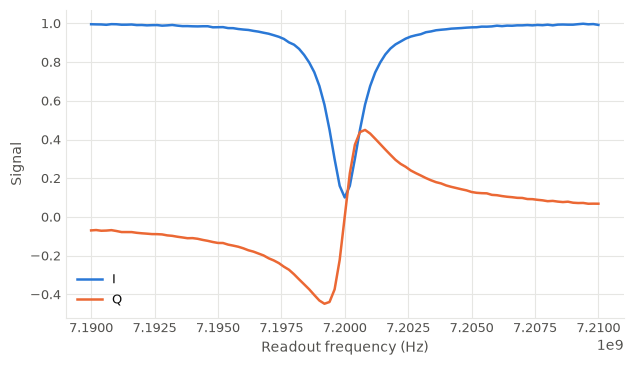

In [23]:
result.plot(m_spec)

Two lines came back because `channels` defaults to the pair of quadratures. `channels="magnitude"` takes the hypotenuse of the two and draws one curve instead, and the y axis renames itself to match.

<Axes: xlabel='Readout frequency (Hz)', ylabel='Magnitude'>

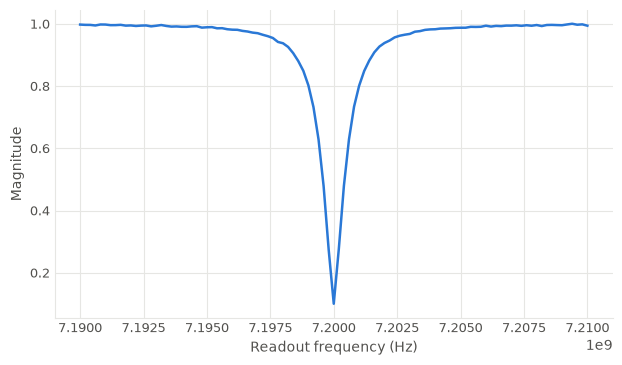

In [24]:
result.plot(m_spec, channels="magnitude")

### Reading the numbers off the curve

`argmin` gives you the centre to one step of the grid, so a 200 kHz grid gives you the resonator to 200 kHz, and Part 3 fits a curve instead.

The width needs one more move. Take the squared magnitude against the off-resonance baseline, then let `np.interp` read the half-maximum crossings between the grid points, which is how the number below lands within 10 kHz of the truth.

In [25]:
freqs = iq.coords["ro_freq"].values
s21_data = iq.sel(IQ="I").values + 1j * iq.sel(IQ="Q").values

f_dip = freqs[np.abs(s21_data).argmin()]

baseline = np.mean(np.concatenate([s21_data[:5], s21_data[-5:]]))  # flat away from resonance
lorentzian = np.abs(baseline - s21_data) ** 2
lorentzian = lorentzian / lorentzian.max()

peak = lorentzian.argmax()
left = np.interp(0.5, lorentzian[: peak + 1], freqs[: peak + 1])  # rising edge
right = np.interp(0.5, lorentzian[peak:][::-1], freqs[peak:][::-1])  # falling edge, reversed

print(f"f_r    measured {f_dip / 1e9:.6f} GHz    true {DEVICE['q0_fr'] / 1e9:.6f} GHz")
print(f"kappa  measured {(right - left) / 1e6:.3f} MHz     true {DEVICE['q0_kappa'] / 1e6:.3f} MHz")
print(f"sweep step {(freqs[1] - freqs[0]) / 1e3:.0f} kHz, so f_r is quantised to that")

f_r    measured 7.200000 GHz    true 7.200000 GHz
kappa  measured 1.509 MHz     true 1.500 MHz
sweep step 200 kHz, so f_r is quantised to that


Everything past the bare call is a decision about the figure rather than about the data, and each one is either an argument you add or a method on the `Axes` that came back. The axis still reads hertz here, so the two reference lines go on in hertz.

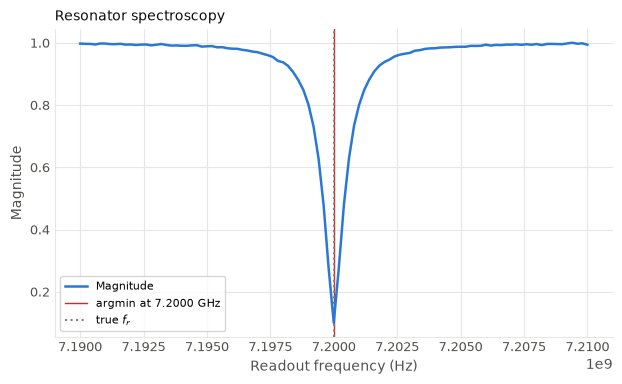

In [26]:
ax = result.plot(m_spec, channels="magnitude", title="Resonator spectroscopy")
ax.axvline(f_dip, color="tab:red", lw=1, label=f"argmin at {f_dip / 1e9:.4f} GHz")
ax.axvline(DEVICE["q0_fr"], color="grey", ls=":", label="true $f_r$")
ax.legend(fontsize=8)

### Restating an axis

A frequency axis wants gigahertz. `coords=` restates a coordinate for the figure alone and leaves the stored array in hertz, and `Quantity(label, units, transform)` reads positionally in that order.

The restatement is a pair wherever there is a claim to falsify. On a coordinate that already declares `units="Hz"`, a `transform` alone would move the numbers under a label that still says hertz, and a `units="GHz"` alone would relabel numbers nobody moved, so both halves or neither. A coordinate that declares no unit takes either half alone, which is how you supply a unit the program never recorded.

The drawn numbers moved, so everything you hand the returned `Axes` afterwards is in the figure's units too. Both reference lines below are divided by `1e9` while `f_dip` itself stays in hertz. `value=` restates the measured quantity the same way, and `style=` carries the choices about the drawing itself, so `Style(markers=True)` puts a marker at every sample, which a 101-point sweep can afford.

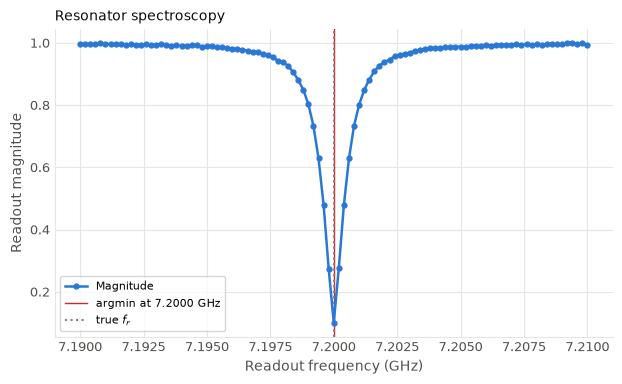

In [27]:
ax = result.plot(
    m_spec,
    channels="magnitude",
    coords={"ro_freq": Quantity(units="GHz", transform=lambda v: v / 1e9)},
    value=Quantity("Readout magnitude"),
    style=Style(markers=True),
    title="Resonator spectroscopy",
)
ax.axvline(f_dip / 1e9, color="tab:red", lw=1, label=f"argmin at {f_dip / 1e9:.4f} GHz")
ax.axvline(DEVICE["q0_fr"] / 1e9, color="grey", ls=":", label="true $f_r$")
ax.legend(fontsize=8)

In [28]:
for half_a_pair in (dict(transform=lambda v: v / 1e9), dict(units="GHz")):
    try:
        result.plot(m_spec, coords={"ro_freq": Quantity(**half_a_pair)})
    except qp.ValidationError as exc:
        print(exc, "\n")

coords['ro_freq'] rescales the values, so the inherited unit 'Hz' no longer describes them and the axis would read (Hz) over numbers that are not in Hz. Pass units= for what they are now, units='' if they are now a bare ratio, or units='Hz' if the transform leaves the unit alone, as subtracting a baseline does. 

coords['ro_freq'] relabels the unit from 'Hz' to 'GHz' without changing the numbers, so the axis would read (GHz) over values still in Hz. Pass the transform= that converts them, or correct the unit on the variable the coordinate came from. 



The same record drawn as phase tells you the other half of the story. Magnitude flattens out when the dip is shallow, and phase stays readable there. The y axis names itself again, because the channel decided it.

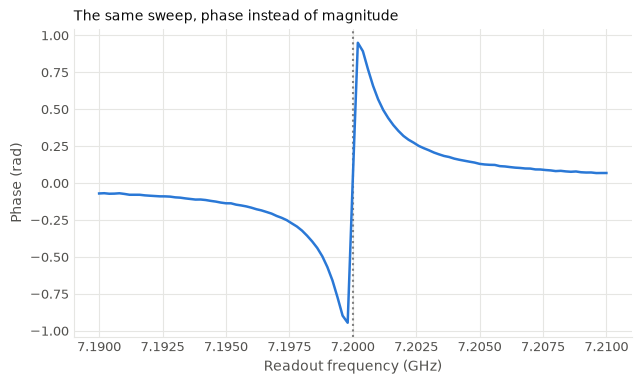

In [29]:
ax_phase = result.plot(
    m_spec,
    channels="phase",
    coords={"ro_freq": Quantity(units="GHz", transform=lambda v: v / 1e9)},
    title="The same sweep, phase instead of magnitude",
)
ax_phase.axvline(DEVICE["q0_fr"] / 1e9, color="grey", ls=":")

## 2.6 Results are xarray

You have been reading these arrays since 2.3, and the container they came out of has gone unopened. `qp.simulate` returns a `QProgramResult` holding the records in construction order, and each one carries the bus it ran on, the name you gave it, and the fields that measurement asked for. `result.get(handle)` hands you an `xarray.DataArray` whose dimensions are the enclosing sweeps, outermost first, named after your variable ids, with the swept values as coordinates, and an integrated measurement carries one extra `IQ` axis of length two.

In [30]:
print(len(result), result)
for record in result.measurements:
    print("  ", record.bus, record.name, sorted(record.fields))

1 QProgramResult(1 measurements, names=['q0/readout/m0'])
   q0/readout q0/readout/m0 ['iq']


### Three ways to name a record

The records are a list rather than a dict, and `get` resolves three spellings against it. A handle says what it means and is the one to prefer. A plain name string selects the same record, and you reach for that after loading a program back from a `.qp` file in a session that never built it. An integer is positional sugar for declaration order. `bus=` narrows the candidates first, so `get(0, bus=q[1].readout)` means the first measurement on that bus, and `plot` takes all three spellings too.

`result.get(handle)` defaults to `field=MF.IQ`. Ask for a field the measurement never requested and you get a `KeyError`, the default included, so a state-only measurement needs `field=MF.STATE` spelled out.

In [31]:
print("by handle:", result.get(m_spec).shape,
      "| by name:", result.get("q0/readout/m0").shape,
      "| by position:", result.get(0).shape)

print(iq.isel(ro_freq=slice(0, 4)))  # the first four rows, so the repr fits on screen

print("\nwhat the variable left on the coordinate:", iq.coords["ro_freq"].attrs)

# Label-based selection is the point of xarray: no index arithmetic, no guessing the axis order.
on_resonance = iq.sel(IQ="I").sel(ro_freq=DEVICE["q0_fr"], method="nearest")
print("I at the resonator:", round(float(on_resonance), 4))

try:
    result.get(m_spec, field=MF.STATE)  # this measurement asked for iq and nothing else
except KeyError as err:
    print("asking for a field that was never requested:", err)

by handle: (101, 2) | by name: (101, 2) | by position: (101, 2)
<xarray.DataArray (ro_freq: 4, IQ: 2)> Size: 64B
array([[ 0.99538331, -0.06951379],
       [ 0.99463926, -0.06772279],
       [ 0.99424955, -0.0712499 ],
       [ 0.99247738, -0.07039821]])
Coordinates:
  * ro_freq  (ro_freq) float64 32B 7.19e+09 7.19e+09 7.19e+09 7.191e+09
  * IQ       (IQ) <U1 8B 'I' 'Q'

what the variable left on the coordinate: {'long_name': 'Readout frequency', 'units': 'Hz'}
I at the resonator: 0.1005
asking for a field that was never requested: "Measurement 'q0/readout/m0' has no field 'state'; available: iq"


## 2.7 Nested sweeps and punchout

Two `with` statements nest two loops, and nesting in the file is nesting in the result. The outer sweep becomes the outer dimension, and shots times points is the number to keep an eye on, in the simulator and on real hardware alike.

The outer variable goes into the readout pulse rather than into an operation, so 2.1's expression in a waveform parameter is here doing a real job. Part 1 was careful that gain and amplitude are two different knobs, and the amplitude is the one this section is about.

The measurement is the reason to nest here. The frequency 2.5 found is the frequency at one readout power, and the resonator only reports on the qubit while the tone stays weak enough for the two to shift each other rather than swap energy. Inverting the $\chi$ of the opening backs out $g \approx 190$ MHz for this chip, and a ceiling near 37 photons. Wrapping a second sweep over the amplitude turns one line into a map of where that limit falls.

In [32]:
def s21_power(bus, env):
    """The resonator sits at f_r + chi at low power and slides to bare f_r as it saturates."""
    saturation = 1.0 / (1.0 + (env["ro_amp"] / 0.35) ** 2)
    f_eff = DEVICE["q0_fr"] + DEVICE["q0_chi"] * saturation
    detuning = (env["ro_freq"] - f_eff) / (DEVICE["q0_kappa"] / 2)
    return 1.0 - 0.9 / (1.0 + 1j * detuning)


punchout = qp.QProgram(label="punchout", schema=schema)
pun_amp = punchout.variable("ro_amp", label="Readout amplitude", units="DAC units")
pun_freq = punchout.variable("ro_freq", label="Readout frequency", units="Hz")

with punchout.average(shots=50):
    with punchout.sweep(pun_amp, qp.Linspace(0.02, 1.0, 25)):
        with punchout.sweep(pun_freq, qp.Linspace(7.1955e9, 7.2025e9, 41)):
            punchout.set_frequency(q[0].readout, pun_freq)
            m_pun = punchout.measure(
                q[0].readout, IQZero(Square(amplitude=pun_amp, duration=2000)), "weights"
            )

print("points:", 25 * 41, "at 50 shots =", 25 * 41 * 50, "samples")

points: 1025 at 50 shots = 51250 samples


In [33]:
punch_result = qp.simulate(
    punchout, model=qp.MockMeasurementModel(response=s21_power, noise=0.02, seed=11)
)
punch_iq = punch_result.get(m_pun)
print("dims:", punch_iq.dims, "shape:", punch_iq.shape, "(outermost sweep first)")

dims: ('ro_amp', 'ro_freq', 'IQ') shape: (25, 41, 2) (outermost sweep first)


<Axes: xlabel='Readout frequency (Hz)', ylabel='Readout amplitude (DAC units)'>

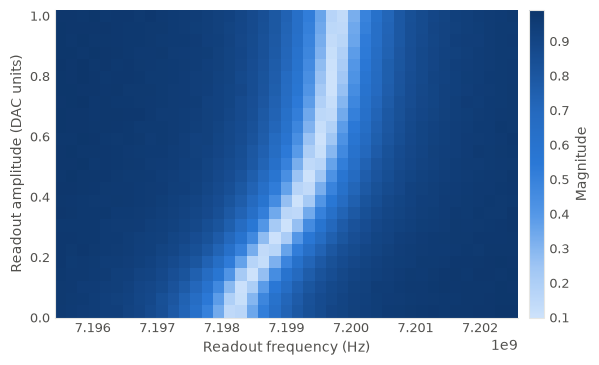

In [34]:
punch_result.plot(m_pun)

Two swept dimensions make a heatmap, with the magnitude on the colour bar because a surface has one number per cell to colour. The inner sweep runs along x and the outer up y, matching the loop nesting, so frequency comes out left to right and power upward without either being asked for. `x=` and `y=` override that, and naming one settles the other.

The white lines below sit at $f_r + \chi$ and at bare $f_r$.

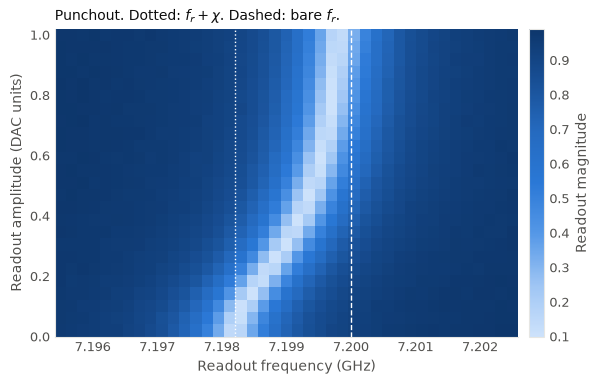

In [35]:
ax_pun = punch_result.plot(
    m_pun,
    coords={"ro_freq": Quantity(units="GHz", transform=lambda v: v / 1e9)},
    value=Quantity("Readout magnitude"),
    title=r"Punchout. Dotted: $f_r + \chi$. Dashed: bare $f_r$.",
)
ax_pun.axvline((DEVICE["q0_fr"] + DEVICE["q0_chi"]) / 1e9, color="w", ls=":", lw=1)
ax_pun.axvline(DEVICE["q0_fr"] / 1e9, color="w", ls="--", lw=1)

In [36]:
punch_mag = np.abs(punch_iq.sel(IQ="I") + 1j * punch_iq.sel(IQ="Q")).values
amps = punch_iq.coords["ro_amp"].values
scan_freqs = punch_iq.coords["ro_freq"].values
dip_per_amp = scan_freqs[punch_mag.argmin(axis=1)]

for k in (0, 12, 24):
    print(f"amplitude {amps[k]:.2f}  ->  dip at {dip_per_amp[k] / 1e9:.6f} GHz")
print(f"low-power target   f_r + chi = {(DEVICE['q0_fr'] + DEVICE['q0_chi']) / 1e9:.6f} GHz")
print(f"high-power target  bare f_r  = {DEVICE['q0_fr'] / 1e9:.6f} GHz")
print(f"frequency step {(scan_freqs[1] - scan_freqs[0]) / 1e3:.0f} kHz,"
      " which is all the accuracy an argmin can have")

amplitude 0.02  ->  dip at 7.198125 GHz
amplitude 0.51  ->  dip at 7.199350 GHz
amplitude 1.00  ->  dip at 7.199875 GHz
low-power target   f_r + chi = 7.198200 GHz
high-power target  bare f_r  = 7.200000 GHz
frequency step 175 kHz, which is all the accuracy an argmin can have


### Choosing a readout power

On this chip the pull has halved by 0.35 in DAC units, which puts the 0.2 that Part 1 wrote into `readout_pulse` about 5 dB under the crossover. Every readout from here to the capstone plays at that amplitude, and this map is the scan that justifies it.

### The log power axis

Readout power spans decades, and a linear amplitude axis spends most of its points at the top end where nothing is moving any more. A `Logspace` sweep puts most of its points below 0.35 where the crossover is, and takes twenty measurements doing it instead of twenty-five.

That costs something at the other end, because `Logspace` is arbitrary where `Linspace` was linear. Twenty points is a cheap table, so the trade goes the right way here, and `KIND` printed below is the declaration a platform reads to decide. The dip depth does not move in this model, so the position carries all of the information in the figure.

A log amplitude axis is not something the result can know you want, so it is `ax.set_yscale("log")` on the axes that comes back.

In [37]:
power_scan = qp.QProgram(label="punchout_log", schema=schema)
log_amp = power_scan.variable("ro_amp", label="Readout amplitude", units="DAC units")
log_freq = power_scan.variable("ro_freq", label="Readout frequency", units="Hz")

with power_scan.average(shots=50):
    with power_scan.sweep(log_amp, qp.Logspace(0.02, 1.0, 20)):
        with power_scan.sweep(log_freq, qp.Linspace(7.1955e9, 7.2025e9, 41)):
            power_scan.set_frequency(q[0].readout, log_freq)
            m_log = power_scan.measure(
                q[0].readout, IQZero(Square(amplitude=log_amp, duration=2000)), "weights"
            )

print("Logspace kind:", qp.Logspace(0.02, 1.0, 20).KIND,
      "against Linspace:", qp.Linspace(0.02, 1.0, 20).KIND)

Logspace kind: arbitrary against Linspace: linear


In [38]:
log_result = qp.simulate(
    power_scan, model=qp.MockMeasurementModel(response=s21_power, noise=0.02, seed=13)
)
log_iq = log_result.get(m_log)
log_amps = log_iq.coords["ro_amp"].values
log_freqs = log_iq.coords["ro_freq"].values
log_mag = np.abs(log_iq.sel(IQ="I") + 1j * log_iq.sel(IQ="Q")).values
log_dip = log_freqs[log_mag.argmin(axis=1)]

print(f"{log_amps[0]:.3f} -> {log_dip[0] / 1e9:.6f} GHz, "
      f"target f_r + chi = {(DEVICE['q0_fr'] + DEVICE['q0_chi']) / 1e9:.6f}")
print(f"{log_amps[-1]:.3f} -> {log_dip[-1] / 1e9:.6f} GHz, "
      f"target bare f_r = {DEVICE['q0_fr'] / 1e9:.6f}")

0.020 -> 7.198125 GHz, target f_r + chi = 7.198200
1.000 -> 7.199875 GHz, target bare f_r = 7.200000


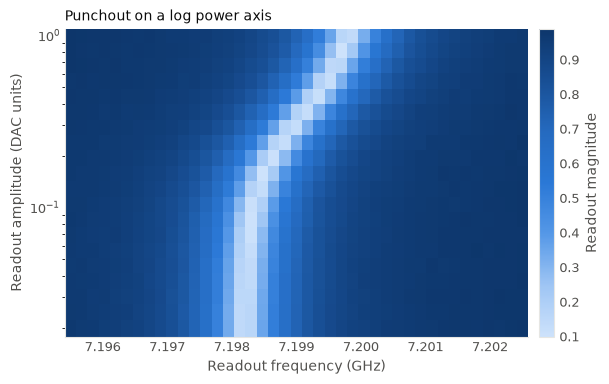

In [39]:
ax_log = log_result.plot(
    m_log,
    coords={"ro_freq": Quantity(units="GHz", transform=lambda v: v / 1e9)},
    value=Quantity("Readout magnitude"),
    title="Punchout on a log power axis",
)
ax_log.set_yscale("log")

### Parallel loops

Either map cost you a rectangle of measurements and most of them were off resonance. Now that you know where the ridge is, you can walk along it instead, stepping the amplitude and the frequency **together**, one point per amplitude.

`sweep(a, src) | sweep(b, src)` is that lockstep pair. Both loops advance on the same tick over one shared body, so they must have the same length, and every source reports its length without running. The `|` itself computes nothing and modifies nothing, so the check fires when the block opens rather than on the line that composed it. That purity is the point rather than an accident. It is what lets a list of sweeps be folded together, and what lets a third `|` chain a third loop.

In the result the pair shares one dimension whose name joins the ids, carrying one coordinate array per composed variable. Point $k$ of one is always paired with point $k$ of the other, and there is no grid. The block it builds is `Parallel`, the last of the three containers Part 1 held over for this part, and it keeps its loops on `.loops` while `.elements` holds the shared body.

A diagonal earns its place whenever the interesting region is a curve rather than a rectangle, and the full map comes first, because you cannot walk a ridge you have not found.

In [40]:
bad = qp.QProgram(label="mismatched", schema=schema)
a = bad.variable("a")
b = bad.variable("b")

pair_of_loops = bad.sweep(a, qp.Linspace(0, 1, 5)) | bad.sweep(b, qp.Linspace(0, 1, 6))
print("the | itself:", type(pair_of_loops).__name__, "and no exception yet")

try:
    with pair_of_loops:
        pass
except qp.ValidationError as exc:
    print("caught when the block opens:", exc)

the | itself: _LoopContext and no exception yet
caught when the block opens: parallel loops must have the same number of iterations to advance in lockstep; got Sweep('a'): 5, Sweep('b'): 6


In [41]:
ridge = qp.QProgram(label="punchout_ridge", schema=schema)
d_amp = ridge.variable("ro_amp", label="Readout amplitude", units="DAC units")
d_freq = ridge.variable("ro_freq", label="Readout frequency", units="Hz")

with ridge.average(shots=50):
    with ridge.sweep(d_amp, qp.Values(amps)) | ridge.sweep(d_freq, qp.Values(dip_per_amp)):
        ridge.set_frequency(q[0].readout, d_freq)
        m_ridge = ridge.measure(
            q[0].readout, IQZero(Square(amplitude=d_amp, duration=2000)), "weights"
        )

pair_block = ridge.body.elements[0].elements[0]
print("block:", type(pair_block).__name__, [s.variable.id for s in pair_block.loops])

block: Parallel ['ro_amp', 'ro_freq']


In [42]:
ridge_result = qp.simulate(
    ridge, model=qp.MockMeasurementModel(response=s21_power, noise=0.02, seed=11)
)
ridge_iq = ridge_result.get(m_ridge)
ridge_mag = np.abs(ridge_iq.sel(IQ="I") + 1j * ridge_iq.sel(IQ="Q")).values

print("dims:  ", ridge_iq.dims, ridge_iq.shape)
print("coords:", list(ridge_iq.coords))
print("measurements:", ridge_iq.sizes["ro_amp|ro_freq"], "against", 25 * 41, "for the full map")
print("|S21| along the ridge:", np.round(ridge_mag[:6], 3), "...")
print("still in the dip everywhere:", bool(ridge_mag.max() < 0.3))

dims:   ('ro_amp|ro_freq', 'IQ') (25, 2)
coords: ['ro_amp', 'ro_freq', 'IQ']
measurements: 25 against 1025 for the full map
|S21| along the ridge: [0.144 0.12  0.113 0.107 0.128 0.142] ...
still in the dip everywhere: True


### Drawing a shared dimension

One dimension carrying two coordinates is more than an axis can hold, and `plot` draws both rather than dropping one. The first variable of the pair goes along the bottom and the second on a twin scale across the top, in the order the loops were written. Those top ticks land on samples instead of round numbers, because tick $k$ and sample $k$ are the same measurement.

<Axes: xlabel='Readout amplitude (DAC units)', ylabel='Magnitude'>

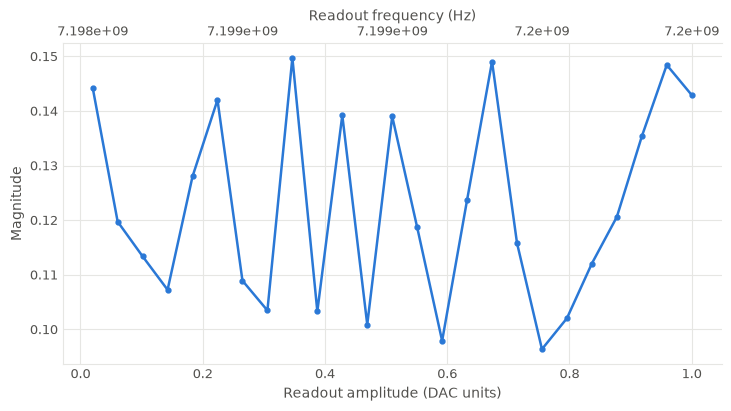

In [43]:
ridge_result.plot(m_ridge, channels="magnitude", style=Style(markers=True))

The twin takes a `coords=` restatement keyed by its own name, so the frequencies below are drawn as a detuning from the bare resonator in megahertz. Left in gigahertz the five ticks would have read 7.198, 7.199, 7.199, 7.2 and 7.2, three labels for twenty-five measurements.

`x=` drops the twin entirely and asks for a bare axis instead, and once dropped, a `coords=` key naming the coordinate that is gone raises rather than doing nothing.

<Axes: title={'left': 'Walking the ridge'}, xlabel='Readout amplitude (DAC units)', ylabel='Magnitude'>

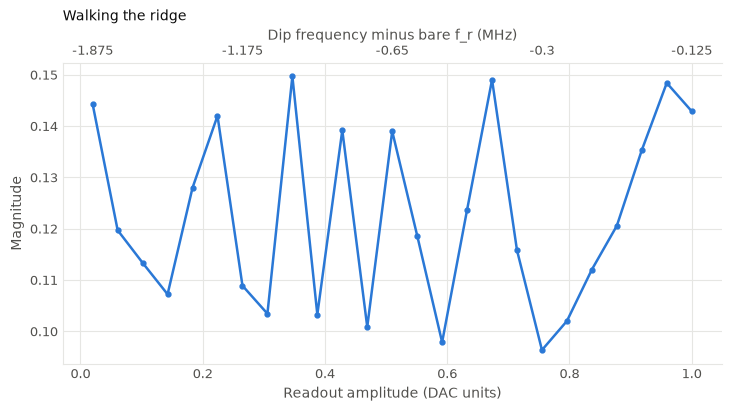

In [44]:
ridge_result.plot(
    m_ridge,
    channels="magnitude",
    coords={
        "ro_freq": Quantity(
            "Dip frequency minus bare f_r", "MHz", lambda v: (v - DEVICE["q0_fr"]) / 1e6
        )
    },
    style=Style(markers=True),
    title="Walking the ridge",
)

### 🧩 Exercise 2.1

Scan both readout resonators in one lockstep pass, then explain the single 41-long dimension that comes back. Qubit 1 has its own readout resonator at 7.35 GHz, and its band does not overlap qubit 0's.

1. Declare `f0` and `f1` and sweep them in parallel with `sweep(f0, ...) | sweep(f1, ...)`. Give each a 41-point `Linspace` over its own 10 MHz band (`7.195` to `7.205` GHz, and `7.345` to `7.355` GHz). Use `shots=100`.
2. Inside the loop, `set_frequency` on each readout bus and `measure` both. You get two handles.
3. Write one response function for both resonators. It receives `bus`, so it can pick which frequency and which centre to use. `DEVICE` has `q1_fr` but no linewidth for qubit 1, so let `q0_kappa` stand in for both.
4. Print the dims of each record and the dip frequency each one found, then write a comment explaining why there is one dimension of length 41 here and not a 41 by 41 grid.
5. Draw each record with `result.plot(handle, channels="magnitude")`. Both records live on the same `"f0|f1"` dimension, so the default reads `f0` below and `f1` above. The q0 record wants that order and the q1 record wants `x="f1"`. Restate the drawn axes into GHz with `coords=`, and note that a `coords=` key naming an axis the figure does not draw raises.

In [ ]:
# TODO: scan both readout resonators in one lockstep sweep.
# 1) f0 over 7.195 to 7.205 GHz, f1 over 7.345 to 7.355 GHz, 41 points each, shots=100.
# 2) with pair.sweep(f0, ...) | pair.sweep(f1, ...):  then set_frequency and measure on both buses.
# 3) One response(bus, env): compare bus to q[0].readout to choose the centre and the env key.
#    DEVICE["q1_fr"] is 7.35e9.
# 4) Print each record's dims and its dip frequency, and explain the single 41-long dimension
#    in a comment.
# 5) result.plot(m_q0, channels="magnitude") reads f0 below and f1 above; the q1 record wants
#    x="f1". Restate the drawn axes into GHz with coords={...: Quantity(units="GHz",
#    transform=lambda v: v / 1e9)}.

## Recap

- A **variable** is a hole in the program, declared with `program.variable(id, label=..., units=...)`. Arithmetic on it builds an expression tree and computes nothing, the tree re-evaluates every iteration, and `label` and `units` follow the data out and label the axes of every figure.
- A **sweep source** says how the variable moves, and a sweep has three spellings, an object, a `from_*` builder, and a bare list meaning `Values`. `Range` and `Linspace` are `linear`, so a sequencer can run them from a register. Everything else is `arbitrary`, and `Range` includes its stop value only when the step divides the span.
- **`average(shots)` adds no dimension.** It shrinks the noise on `iq` and turns `state` from a 0/1 outcome into a population, and it still costs a repetition level on the sequencer.
- The **measurement model** is the only thing in the run that produces a number. Every figure in this notebook came out of a `response(bus, env)` you can read.
- Results are **xarray**, one dimension per enclosing sweep, outermost first, named after your variable ids, with one shared `"a|b"` dimension for a parallel pair. `get` takes a handle, a name or an integer, and `result.plot` picks a line for one swept dimension and a heatmap for two, then returns the `Axes` your fits and reference lines go on.

## Next

You now have the bare resonator, its linewidth, and a punchout map that says what amplitude to read out at. Part 3 puts a second tone on the drive line and goes looking for the qubit itself.